# ¡Hola Max! 😊

Mi nombre es **Alejandro Castellanos** y hoy tengo el placer de ser el revisor de tu proyecto.

Voy a revisar todo tu código con detalle, buscando tanto los puntos fuertes como aquellos en los que podrías mejorar. Te dejaré comentarios a lo largo del notebook, destacando lo que has hecho bien y sugiriendo ajustes donde sea necesario. Si encuentro algún error, no te preocupes, te lo haré saber de forma clara y te daré información útil para que puedas corregirlo en la próxima iteración. Si en algún punto tienes comentarios, siéntete libre de dejarlos también.


Encontrarás mis comentarios específicos dentro de cajas verdes, amarillas o rojas, es muy importante que no muevas, modifiques o borres mis comentarios, con el fin de tener un seguimiento adecuado de tu proceso:


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si todo está perfecto.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si tu código está bien pero se puede mejorar o hay algún detalle que le hace falta.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si de pronto hace falta algo o existe algún problema con tu código o conclusiones.
</div>

Puedes responderme de esta forma:
<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class=“tocSkip”></a>
</div>

A continuación te dejaré un comentario general con mi valoración del proyecto. **¡Mi objetivo es que sigas aprendiendo y mejorando con cada paso!**


-----

<div class="alert alert-block alert-success">
<b>Comentario General del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Max completaste todas las tareas propuestas para el proyecto de manera sobresaliente. Demostraste un excelente manejo de las herramientas de manipulación y visualización de datos.

Como sugerencia para fortalecer aún más tu análisis estadístico, sería conveniente incorporar la prueba de Levene antes de realizar comparaciones de medias, ya que esto asegurará que tus resultados sean más robustos y confiables.

Continúa desarrollando estas habilidades, ya que serán claves en futuros proyectos.

Éxitos en tu próximo sprint 🚀

*Estado del Proyecto:* **Aprobado**

</div>

-----

# Proyecto Sprint 8 - Analisis de viajes en taxi en Chicago (Zuber)

## Introducción

Zuber es una nueva empresa de viajes compartidos que busca comprender el comportamiento del mercado de taxis en Chicago. El objetivo de este proyecto es analizar los patrones de viaje, identificar las zonas con mayor demanda y determinar si las condiciones climáticas influyen en la duración de los trayectos entre Loop y el Aeropuerto Internacional O'Hare. Los resultados obtenidos permitirán generar recomendaciones útiles para la toma de decisiones operativas y estratégicas.

## Paso 1 - Web Scraping
Obtenemos los datos del clima de Chicago de noviembre 2017 desde el sitio web 

In [22]:

import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Web scraping
weather_records = pd.read_html(
    'https://practicum-content.s3.us-west-1.amazonaws.com/data-analyst-eng/moved_chicago_weather_2017.html',
    attrs={"id": "weather_records"}
)[0]

print(weather_records)

           Date and time  Temperature       Description
0    2017-11-01 00:00:00       276.15     broken clouds
1    2017-11-01 01:00:00       275.70  scattered clouds
2    2017-11-01 02:00:00       275.61   overcast clouds
3    2017-11-01 03:00:00       275.35     broken clouds
4    2017-11-01 04:00:00       275.24     broken clouds
..                   ...          ...               ...
692  2017-11-29 20:00:00       281.34        few clouds
693  2017-11-29 21:00:00       281.69      sky is clear
694  2017-11-29 22:00:00       281.07        few clouds
695  2017-11-29 23:00:00       280.06      sky is clear
696  2017-11-30 00:00:00       278.46      sky is clear

[697 rows x 3 columns]


## Conclusión - Web Scraping

Se obtuvieron exitosamente 697 registros meteorológicos de Chicago correspondientes a noviembre de 2017 mediante técnicas de web scraping.

El conjunto de datos contiene información sobre la fecha y hora del registro, la temperatura y la descripción de las condiciones climáticas, recopiladas de manera horaria a lo largo del mes.

Además, no se identificaron valores ausentes en las columnas analizadas, y los datos cubren completamente el período de estudio. Por ello, el dataset se considera adecuado para investigar la posible influencia de las condiciones climáticas sobre la duración de los viajes en taxi en Chicago.

## Paso 4 - Analisis Exploratorio
Cargamos y exploramos los dos archivos CSV con datos de empresas de taxis y barrios 

In [23]:
df_01 = pd.read_csv('/datasets/project_sql_result_01.csv')
df_04 = pd.read_csv('/datasets/project_sql_result_04.csv')

print(df_01.head())
print(df_01.info())
print()
print(df_04.head())
print(df_04.info())

                      company_name  trips_amount
0                        Flash Cab         19558
1        Taxi Affiliation Services         11422
2                Medallion Leasing         10367
3                       Yellow Cab          9888
4  Taxi Affiliation Service Yellow          9299
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB
None

  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Muy buen trabajo importando las librerías y los datos del proyecto. Adicionalmente usaste correctamente las funciones `info` y `head`, esto te permite hacer una primera revisión de los datos, su estructura y contenido.

</div>

In [24]:
# Verificar y corregir tipos de datos
print("df_01 tipos de datos:")
print(df_01.dtypes)
print()
print("df_04 tipos de datos:")
print(df_04.dtypes)

df_01['trips_amount'] = df_01['trips_amount'].astype(int)
df_04['average_trips'] = df_04['average_trips'].astype(float)

print("\nTipos después de verificación:")
print(df_01.dtypes)
print(df_04.dtypes)

df_01 tipos de datos:
company_name    object
trips_amount     int64
dtype: object

df_04 tipos de datos:
dropoff_location_name     object
average_trips            float64
dtype: object

Tipos después de verificación:
company_name    object
trips_amount     int64
dtype: object
dropoff_location_name     object
average_trips            float64
dtype: object


In [25]:
# Top 10 barrios por finalizaciones
top_10 = df_04.sort_values('average_trips', ascending=False).head(10)
print("Top 10 barrios por finalizaciones:")
print(top_10)

Top 10 barrios por finalizaciones:
  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000
5             Lake View    2420.966667
6            Grant Park    2068.533333
7         Museum Campus    1510.000000
8            Gold Coast    1364.233333
9    Sheffield & DePaul    1259.766667


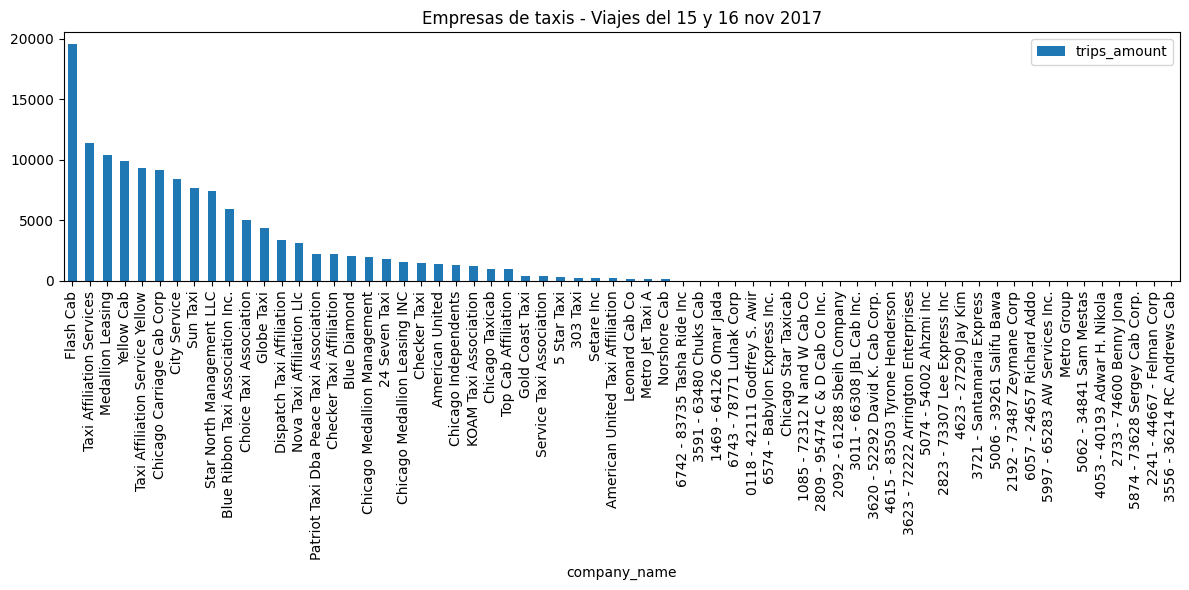

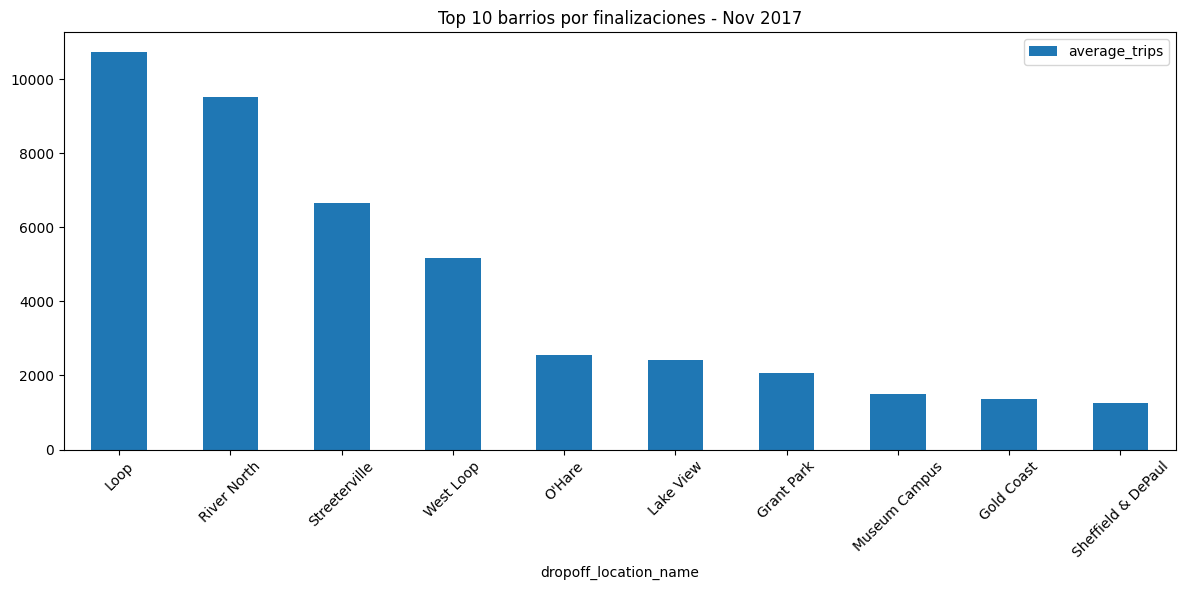

In [26]:
# Gráfico 1: empresas de taxis
df_01.sort_values('trips_amount', ascending=False).plot(
    x='company_name', y='trips_amount', kind='bar', figsize=(12,6),
    title='Empresas de taxis - Viajes del 15 y 16 nov 2017'
)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Gráfico 2: top 10 barrios
df_04.sort_values('average_trips', ascending=False).head(10).plot(
    x='dropoff_location_name', y='average_trips', kind='bar', figsize=(12,6),
    title='Top 10 barrios por finalizaciones - Nov 2017'
)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Muy buen trabajo con las gráficas, se logra identificar de forma clara la distribución de viajes por compañía y barrio

</div>


## Conclusiones del análisis exploratorio

### Gráfico 1 - Empresas de taxis

Flash Cab fue la empresa con el mayor número de viajes durante el período analizado, registrando aproximadamente 20,000 trayectos, casi el doble que su competidor más cercano, Taxi Affiliation Services. Además, se observa una fuerte concentración del mercado en unas pocas compañías, ya que las primeras empresas acumulan la mayor parte de los viajes, mientras que el resto presenta una participación considerablemente menor.

### Gráfico 2 - Top 10 barrios

Loop fue el barrio con el mayor promedio de finalizaciones de viajes, seguido por River North y Streeterville. Los cuatro primeros barrios corresponden a zonas céntricas de Chicago, lo que sugiere que estas áreas concentran una gran actividad comercial, turística y laboral. En consecuencia, la demanda de servicios de taxi es significativamente mayor en estas ubicaciones que en el resto de la ciudad.

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Buen trabajo al relacionar los resultados con el comportamiento del servicio en la ciudad, porque no te quedas solo en identificar quién lidera y qué zonas tienen más actividad, sino que también conectas esos patrones con una posible concentración del mercado y con la dinámica comercial, turística y laboral de las áreas centrales. Eso muestra que sabes pasar del dato a una lectura con sentido y que entiendes cómo la ubicación influye en la demanda del transporte.

</div>

## Paso 5 - Prueba de Hipótesis

### Hipótesis

- H₀ (hipótesis nula): La duración promedio de los viajes desde Loop hasta el Aeropuerto O'Hare durante los sábados lluviosos es igual a la duración promedio observada en sábados sin lluvia.

- H₁ (hipótesis alternativa): La duración promedio de los viajes desde Loop hasta el Aeropuerto O'Hare durante los sábados lluviosos es diferente a la duración promedio observada en sábados sin lluvia.

### Criterios utilizados

- Nivel de significancia (α = 0.05): Se seleccionó el valor estándar utilizado en análisis estadísticos, aceptando un 5% de probabilidad de cometer un error tipo I (rechazar la hipótesis nula cuando es verdadera).

- Prueba estadística: Se utilizó una prueba t de Student para comparar la duración promedio de los viajes entre dos grupos independientes: viajes realizados en condiciones climáticas favorables y viajes realizados en condiciones climáticas desfavorables. El objetivo es determinar si las diferencias observadas entre ambos grupos son estadísticamente significativas.

In [27]:
df_07 = pd.read_csv('/datasets/project_sql_result_07.csv')

print(df_07.head())
print(df_07.info())

# Separar grupos
bad_weather = df_07[df_07['weather_conditions'] == 'Bad']['duration_seconds']
good_weather = df_07[df_07['weather_conditions'] == 'Good']['duration_seconds']

# Prueba t de Student
alfa = 0.05
resultado = stats.ttest_ind(bad_weather, good_weather)

print(f'\nvalor p: {resultado.pvalue}')

if resultado.pvalue < alfa:
    print('Rechazamos la hipótesis nula: la duración SÍ cambia en días lluviosos')
else:
    print('No rechazamos la hipótesis nula: la duración NO cambia significativamente')

              start_ts weather_conditions  duration_seconds
0  2017-11-25 16:00:00               Good            2410.0
1  2017-11-25 14:00:00               Good            1920.0
2  2017-11-25 12:00:00               Good            1543.0
3  2017-11-04 10:00:00               Good            2512.0
4  2017-11-11 07:00:00               Good            1440.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   start_ts            1068 non-null   object 
 1   weather_conditions  1068 non-null   object 
 2   duration_seconds    1068 non-null   float64
dtypes: float64(1), object(2)
memory usage: 25.2+ KB
None

valor p: 6.517970327099473e-12
Rechazamos la hipótesis nula: la duración SÍ cambia en días lluviosos


## Conclusión - Prueba de hipotesis 

El valor p obtenido fue de 6.5 × 10⁻¹², significativamente menor que el nivel de significancia establecido (α = 0.05).

Por lo tanto, se rechaza la hipótesis nula y se concluye que existe evidencia estadísticamente significativa para afirmar que las condiciones climáticas influyen en la duración de los viajes desde Loop hasta el Aeropuerto Internacional O'Hare durante los sábados.

Estos resultados sugieren que la lluvia afecta los tiempos de traslado, probablemente debido a una disminución en la velocidad del tráfico y a condiciones de conducción más complejas. En consecuencia, Zuber debería considerar las condiciones meteorológicas como un factor relevante al estimar tiempos de viaje, planificar la disponibilidad de conductores y optimizar la experiencia de sus usuarios.

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>


Max aplicaste correctamente la prueba de hipótesis comparando la distribución de dos muestras independientes e interpretando de manera acertada el *p-value* obtenido y su relación con la hipótesis nula, logrando comprobar que el clima sí afecta la duración de los viajes en Taxi

<div class="alert alert-block alert-warning">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Te recomiendo realizar previamente una prueba de Levene para evaluar la igualdad de las varianzas, lo que te permitirá configurar adecuadamente el parámetro **equal_var** en la función `ttest_ind`. Esto te brindará una interpretación más precisa de los resultados además garantizará que la *prueba t* sea estadísticamente válida.

</div>
</div>

## Conclusión General del Proyecto

A lo largo de este proyecto se analizaron los patrones de viajes en taxi en Chicago con el objetivo de identificar oportunidades estratégicas para la empresa Zuber.

Los resultados mostraron que el mercado se encuentra altamente concentrado, con Flash Cab liderando ampliamente en número de viajes respecto a sus competidores. Esto sugiere que unas pocas empresas dominan gran parte de la demanda actual del servicio.

Asimismo, el análisis de los barrios reveló que zonas céntricas como Loop, River North y Streeterville concentran la mayor cantidad de finalizaciones de viajes. Esto indica que el centro de Chicago representa una de las áreas más importantes para la operación de servicios de transporte y debería considerarse una prioridad en la estrategia de expansión de Zuber.

Por otra parte, la prueba de hipótesis permitió comprobar que las condiciones climáticas tienen un efecto significativo sobre la duración de los viajes. Los resultados estadísticos mostraron que los sábados lluviosos presentan tiempos de traslado diferentes a los observados en condiciones climáticas favorables, especialmente en la ruta entre Loop y el Aeropuerto Internacional O'Hare.

En conjunto, estos hallazgos proporcionan información valiosa para la toma de decisiones de negocio, permitiendo a Zuber comprender mejor la dinámica del mercado, identificar las zonas con mayor demanda y considerar el impacto del clima en la planificación de sus operaciones.

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Logras integrar muy bien los distintos análisis del proyecto en una visión útil para la toma de decisiones, conectando la competencia del mercado, la concentración de la demanda en zonas clave y el efecto del clima sobre la operación del servicio. Se nota que no presentas los hallazgos como datos aislados, sino como elementos que ayudan a pensar una estrategia más clara para Zuber y a entender mejor cómo se mueve el negocio en la ciudad.

Para futuros trabajos, te ayudaría dar un paso más en la interpretación estratégica y proponer acciones más concretas a partir de los resultados, por ejemplo en términos de cobertura, horarios o planificación operativa.


</div>